# Proyek Analisis Data Penjualan UMKM (Foreca)


## Menentukan Pertanyaan Bisnis


- **Q1 (tren):** seperti apa tren penjualan (harian & bulanan) dan kapan terjadi perubahan yang paling mencolok?
- **Q2 (produk):** produk mana yang kontribusinya paling besar ke revenue, dan seberapa terpusat revenue-nya (Pareto)?
- **Q3 (aksi):** dari tren + produk dominan + hari puncak, tindakan apa yang realistis untuk UMKM?
- **Q4 (handoff):** gimana format data yang paling aman untuk training forecasting 7 hari?


## Import Semua Packages/Library yang Digunakan


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## Data Wrangling


### Gathering Data


Load dataset `data_penjualan.csv` (delimiter `;`).


In [42]:
# Load CSV (delimiter ';')
df_raw = pd.read_csv("/content/dataset/data_penjualan.csv", sep=";")

print("Shape:", df_raw.shape)
display(df_raw.head(10))


Shape: (1076, 5)


,Tanggal,Jenis Produk,Jumlah Order,Harga,Total
0,05/08/2022,Foodpak260,1000,1800,1800000
1,05/08/2022,FoodpakMatte245,1000,1900,1900000
2,05/08/2022,CraftLaminasi290,5000,750,3750000
3,05/08/2022,CraftLaminasi290,1000,1200,1200000
4,07/08/2022,Dupleks310,1000,1550,1550000
5,08/08/2022,Dupleks310,500,1900,950000
6,08/08/2022,Ivory270,1000,1700,1700000
7,09/08/2022,Kinstruk130,1000,1000,1000000
8,09/08/2022,HVS,1500,850,1275000
9,09/08/2022,Dupleks350,500,1800,900000


### Assessing Data


Cek kualitas data: tipe kolom, missing, duplikasi, dan konsistensi `Total=Qty*Harga`.


In [43]:
# Cek tipe data
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Tanggal       1076 non-null   object
 1   Jenis Produk  1076 non-null   object
 2   Jumlah Order  1076 non-null   int64 
 3   Harga         1076 non-null   int64 
 4   Total         1076 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 42.2+ KB


In [44]:
# Cek missing values
print("Missing values per kolom:")
print(df_raw.isna().sum())


Missing values per kolom:
Tanggal         0
Jenis Produk    0
Jumlah Order    0
Harga           0
Total           0
dtype: int64


In [45]:
# Cek duplikasi baris identik
dup_count = df_raw.duplicated().sum()
print("Duplikasi baris identik:", dup_count)


Duplikasi baris identik: 40


In [46]:
# Validasi aturan bisnis: Total = Jumlah Order * Harga
valid_mask = (df_raw["Jumlah Order"] * df_raw["Harga"] == df_raw["Total"])
valid_rate = valid_mask.mean()
print(f"Proporsi valid Total=Qty*Harga: {valid_rate:.4f}")


Proporsi valid Total=Qty*Harga: 1.0000


- Missing values = **0**.
- Duplikasi baris identik = **40** (akan di-drop saat cleaning agar agregasi tidak double-count).
- `Total = Jumlah Order * Harga` valid **100%** → `Total` aman dipakai sebagai revenue.


### Cleaning Data


Drop duplikasi identik + parsing tanggal (DD/MM/YYYY). Fokusnya biar aman untuk agregasi tren & forecasting.


In [47]:
# Copy agar aman
df = df_raw.copy()

# 1) Drop duplikasi baris identik
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Drop duplicates:", before - len(df))

# 2) Parsing tanggal (DD/MM/YYYY)
df["Tanggal"] = pd.to_datetime(df["Tanggal"].astype(str).str.strip(), dayfirst=True, errors="coerce")
invalid_date = df["Tanggal"].isna().sum()
print("Tanggal invalid:", invalid_date)
if invalid_date > 0:
    df = df.dropna(subset=["Tanggal"]).reset_index(drop=True)

# 3) Pastikan numerik
for c in ["Jumlah Order", "Harga", "Total"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape setelah cleaning:", df.shape)
df.info()
df.head()


Drop duplicates: 40
Tanggal invalid: 0
Shape setelah cleaning: (1036, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036 entries, 0 to 1035
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Tanggal       1036 non-null   datetime64[ns]
 1   Jenis Produk  1036 non-null   object        
 2   Jumlah Order  1036 non-null   int64         
 3   Harga         1036 non-null   int64         
 4   Total         1036 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 40.6+ KB


,Tanggal,Jenis Produk,Jumlah Order,Harga,Total
0,2022-08-05,Foodpak260,1000,1800,1800000
1,2022-08-05,FoodpakMatte245,1000,1900,1900000
2,2022-08-05,CraftLaminasi290,5000,750,3750000
3,2022-08-05,CraftLaminasi290,1000,1200,1200000
4,2022-08-07,Dupleks310,1000,1550,1550000


In [48]:
# Sanity check nilai numerik (negatif/0)
for c in ["Jumlah Order", "Harga", "Total"]:
    print(f"\n[{c}] min={df[c].min()} max={df[c].max()} zero={(df[c]==0).sum()} neg={(df[c]<0).sum()}")



[Jumlah Order] min=5 max=40000 zero=0 neg=0

[Harga] min=100 max=99970 zero=0 neg=0

[Total] min=15376 max=21493550 zero=0 neg=0


Setelah cleaning, data jadi **1036×5**, duplikat terhapus **40 baris**, dan tidak ada tanggal invalid. Sanity check numerik juga aman (tidak ada 0/negatif).


## Feature Engineering


Tambahkan fitur waktu yang kepake buat tren, analisis penyebab, dan preparation forecasting.


In [49]:
# Fitur waktu
df["Tahun"] = df["Tanggal"].dt.year
df["Bulan"] = df["Tanggal"].dt.to_period("M").astype(str)
df["Bulan_Num"] = df["Tanggal"].dt.month
df["Hari"] = df["Tanggal"].dt.day_name()
df["Hari_Ke"] = df["Tanggal"].dt.dayofweek

df[["Tanggal", "Tahun", "Bulan", "Hari", "Hari_Ke"]].head()


,Tanggal,Tahun,Bulan,Hari,Hari_Ke
0,2022-08-05,2022,2022-08,Friday,4
1,2022-08-05,2022,2022-08,Friday,4
2,2022-08-05,2022,2022-08,Friday,4
3,2022-08-05,2022,2022-08,Friday,4
4,2022-08-07,2022,2022-08,Sunday,6


## Exploratory Data Analysis (EDA)


### Statistik Deskriptif (Numerik)


Tujuannya dilakukan biar tahu angka “tipikal” dan seberapa besar ekor/outlier-nya yang penting buat tren & modeling.


In [50]:
num_cols = ["Jumlah Order", "Harga", "Total"]
display(df[num_cols].describe().T)

q = df[num_cols].quantile([0.01, 0.05, 0.95, 0.99]).T
q.columns = ["p01", "p05", "p95", "p99"]
display(q)


,count,mean,std,min,25%,50%,75%,max
Jumlah Order,1036.0,1.939873e+03,2.540335e+03,5.0,1000.0,1000.0,2000.0,40000.0
Harga,1036.0,1.699154e+03,3.414782e+03,100.0,950.0,1500.0,1800.0,99970.0
Total,1036.0,2.372408e+06,1.749042e+06,15376.0,1312500.0,1850000.0,3000000.0,21493550.0


,p01,p05,p95,p99
Jumlah Order,100.0,1000.0,5000.0,16500.0
Harga,250.0,300.0,2700.0,10092.5
Total,250000.0,400000.0,6000000.0,8342500.0


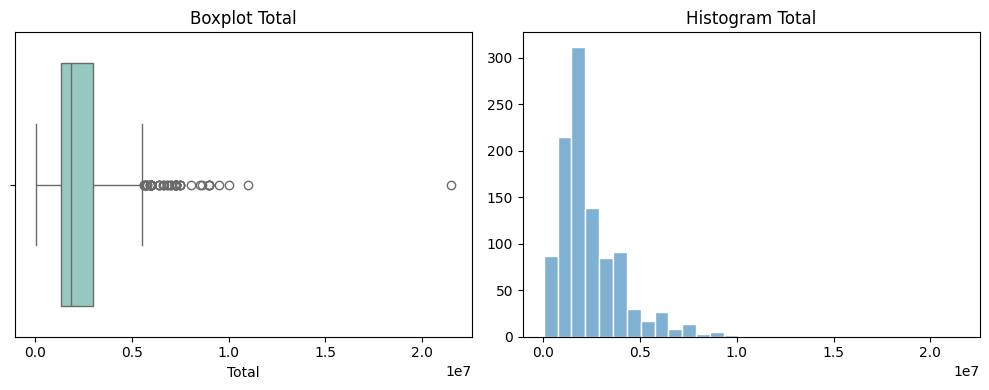

In [51]:
# Cek sebaran revenue
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=df["Total"], color="#8dd3c7")
plt.title("Boxplot Total")

plt.subplot(1, 2, 2)
plt.hist(df["Total"], bins=30, color="#80b1d3", edgecolor="white")
plt.title("Histogram Total")

plt.tight_layout()
plt.show()


`Total` punya rentang **Rp15.376 – Rp21.493.550**. Jadi wajar kalau grafik harian nanti kelihatan naik-turun tajam saat ada order besar.


### Analisis Produk


1.   Produk sering muncul.
2.   Produk paling ngasih revenue.


In [52]:
print("Jumlah produk unik:", df["Jenis Produk"].nunique())
df["Jenis Produk"].value_counts().head()


Jumlah produk unik: 94


,count
Jenis Produk,
Dupleks310,150
Ivory230,126
CraftLaminasi290,120
GreaseProof,75
Dupleks350,74


In [53]:
prod_rev = df.groupby("Jenis Produk")["Total"].sum().sort_values(ascending=False)
prod_rev.head()


,Total
Jenis Produk,
Dupleks310,369140000
CraftLaminasi290,326737500
Ivory230,224061000
Dupleks350,222125000
FoodpakMatte245,152900000


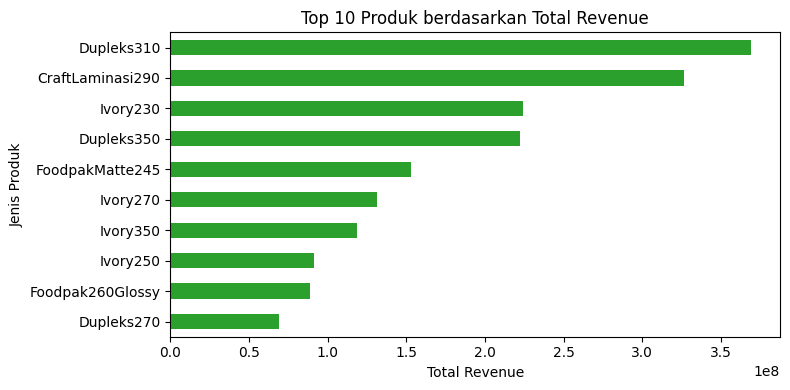

In [54]:
# Top 10 produk berdasarkan revenue
top10 = prod_rev.head(10).sort_values()
plt.figure(figsize=(8, 4))
top10.plot(kind="barh", color="#2ca02c")
plt.title("Top 10 Produk berdasarkan Total Revenue")
plt.xlabel("Total Revenue")
plt.tight_layout()
plt.show()


In [55]:
# Produk top revenue ini juga sering muncul atau tidak?
prod_freq = df["Jenis Produk"].value_counts()
check = pd.DataFrame({"freq": prod_freq, "revenue": prod_rev}).fillna(0)
display(check.loc[prod_rev.head(10).index].sort_values("revenue", ascending=False))


,freq,revenue
Jenis Produk,,
Dupleks310,150,369140000
CraftLaminasi290,120,326737500
Ivory230,126,224061000
Dupleks350,74,222125000
FoodpakMatte245,53,152900000
Ivory270,53,131230000
Ivory350,24,118600000
Ivory250,51,91100000
Foodpak260Glossy,15,88900000


Produk unik = **94**. Top 5 revenue: Dupleks310 (**Rp369.140.000**), CraftLaminasi290 (**Rp326.737.500**), Ivory230 (**Rp224.061.000**), Dupleks350 (**Rp222.125.000**), FoodpakMatte245 (**Rp152.900.000**). Ini wajar jadi fokus stok/operasional.


### Pareto Produk (Konsentrasi Revenue)


Cek berapa produk yang sudah “menutup” ~80% revenue.


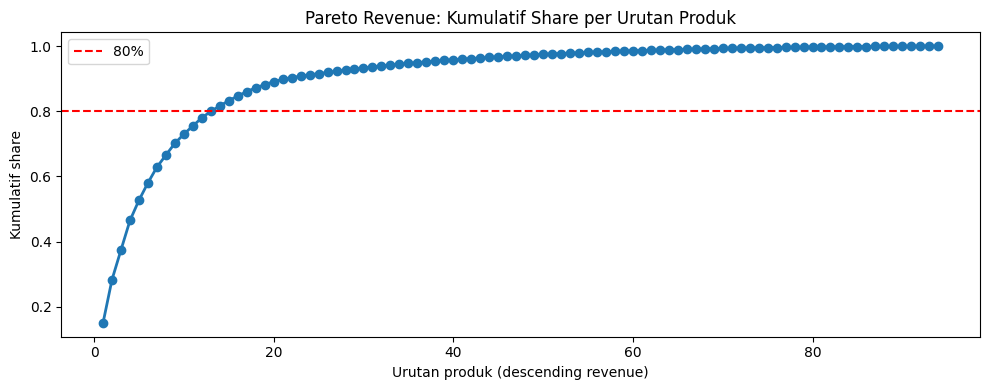

Produk untuk ~80% revenue: 14


In [56]:
prod_rev_all = df.groupby("Jenis Produk", as_index=False)["Total"].sum().sort_values("Total", ascending=False)
prod_rev_all["share"] = prod_rev_all["Total"] / prod_rev_all["Total"].sum()
prod_rev_all["cum_share"] = prod_rev_all["share"].cumsum()

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(prod_rev_all) + 1), prod_rev_all["cum_share"], marker="o", linewidth=2)
plt.axhline(0.8, color="red", linestyle="--", label="80%")
plt.title("Pareto Revenue: Kumulatif Share per Urutan Produk")
plt.xlabel("Urutan produk (descending revenue)")
plt.ylabel("Kumulatif share")
plt.legend()
plt.tight_layout()
plt.show()

n80 = int((prod_rev_all["cum_share"] <= 0.8).sum()) + 1
print("Produk untuk ~80% revenue:", n80)


Untuk menutup ~80% revenue butuh sekitar **14 produk** → revenue cukup terpusat. Praktisnya, jagain stok & bahan untuk produk inti dulu.


## Visualisasi Data & Explanatory Analysis


### Tren Bulanan + Perubahan MoM


Agregasi bulanan dipakai supaya insight tren lebih stabil dan gampang dipresentasikan di dashboard/slide.


In [57]:
monthly = df.groupby("Bulan", as_index=False)["Total"].sum()
monthly["Bulan_dt"] = pd.to_datetime(monthly["Bulan"] + "-01")
monthly = monthly.sort_values("Bulan_dt")
monthly["MoM_abs"] = monthly["Total"].diff()
monthly["MoM_pct"] = monthly["Total"].pct_change() * 100
display(monthly)


,Bulan,Total,Bulan_dt,MoM_abs,MoM_pct
0,2022-08,112270000,2022-08-01,NaN,NaN
1,2022-09,157940000,2022-09-01,45670000.0,40.678721
2,2022-10,122247500,2022-10-01,-35692500.0,-22.598772
3,2022-11,141677500,2022-11-01,19430000.0,15.893986
4,2022-12,172340000,2022-12-01,30662500.0,21.642463
5,2023-01,157837500,2023-01-01,-14502500.0,-8.415052
6,2023-02,128140376,2023-02-01,-29697124.0,-18.814999
7,2023-03,138253500,2023-03-01,10113124.0,7.892223
8,2023-04,161946050,2023-04-01,23692550.0,17.137035
9,2023-05,177975000,2023-05-01,16028950.0,9.897710


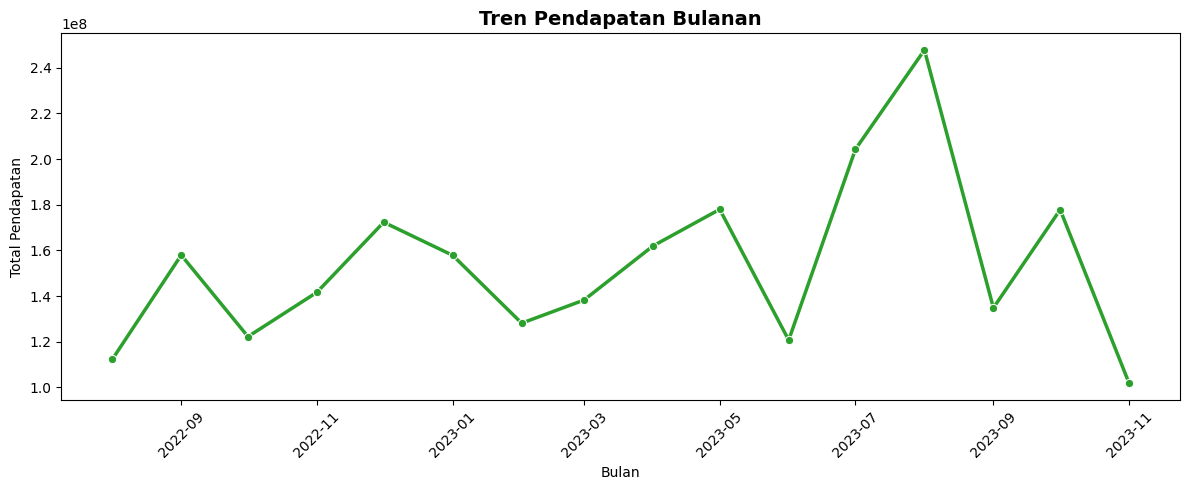

In [58]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="Bulan_dt", y="Total", marker="o", linewidth=2.5, color="#2ca02c")
plt.title("Tren Pendapatan Bulanan", fontsize=14, fontweight="bold")
plt.xlabel("Bulan")
plt.ylabel("Total Pendapatan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Bulan puncak ada di **2023-08** (≈ **Rp247.747.500**). Biasanya puncak bulanan seperti ini muncul karena beberapa hari dengan order besar.


### Tren Harian (Forecasting-ready)


Membuat series harian yang kontinu (tanpa tanggal bolong). Hari tanpa transaksi diasumsikan 0.


In [59]:
daily = (
    df.groupby("Tanggal", as_index=False)
      .agg(Total=("Total", "sum"),
           Jumlah_Order=("Jumlah Order", "sum"),
           Transaksi_Count=("Total", "size"),
           Unique_Produk=("Jenis Produk", "nunique"))
      .sort_values("Tanggal")
)

full_days = pd.DataFrame({"Tanggal": pd.date_range(daily["Tanggal"].min(), daily["Tanggal"].max(), freq="D")})
daily_full = full_days.merge(daily, on="Tanggal", how="left").fillna({
    "Total": 0,
    "Jumlah_Order": 0,
    "Transaksi_Count": 0,
    "Unique_Produk": 0,
})

daily_full["Hari"] = daily_full["Tanggal"].dt.day_name()
daily_full["Hari_Ke"] = daily_full["Tanggal"].dt.dayofweek

print("Rentang tanggal:", df["Tanggal"].min().date(), "->", df["Tanggal"].max().date())
print("Hari terobservasi (ada transaksi):", daily["Tanggal"].nunique())
print("Hari total (kontinu):", len(daily_full))
print("Hari tanpa transaksi:", int((daily_full["Total"] == 0).sum()))
daily_full.head()


Rentang tanggal: 2022-08-05 -> 2023-11-15
Hari terobservasi (ada transaksi): 284
Hari total (kontinu): 468
Hari tanpa transaksi: 184


,Tanggal,Total,Jumlah_Order,Transaksi_Count,Unique_Produk,Hari,Hari_Ke
0,2022-08-05,8650000.0,8000.0,4.0,3.0,Friday,4
1,2022-08-06,0.0,0.0,0.0,0.0,Saturday,5
2,2022-08-07,1550000.0,1000.0,1.0,1.0,Sunday,6
3,2022-08-08,2650000.0,1500.0,2.0,2.0,Monday,0
4,2022-08-09,3175000.0,3000.0,3.0,3.0,Tuesday,1


In [60]:
# Eksplor 10 hari dengan revenue tertinggi
daily_full.sort_values("Total", ascending=False).head()


,Tanggal,Total,Jumlah_Order,Transaksi_Count,Unique_Produk,Hari,Hari_Ke
154,2023-01-06,125637500.0,108500.0,53.0,20.0,Friday,4
132,2022-12-15,76437500.0,51200.0,35.0,22.0,Thursday,3
80,2022-10-24,46395000.0,29200.0,22.0,12.0,Monday,0
50,2022-09-24,43325000.0,31000.0,19.0,10.0,Saturday,5
45,2022-09-19,37075000.0,25000.0,12.0,6.0,Monday,0


In [61]:
# Eksplor seberapa besar kontribusi top 10 hari terhadap total revenue?
top10_share = daily_full.sort_values("Total", ascending=False).head(10)["Total"].sum() / daily_full["Total"].sum()
print(f"Kontribusi top 10 hari: {top10_share:.1%}")


Kontribusi top 10 hari: 19.2%


,Total,Jumlah_Order,Transaksi_Count,Unique_Produk
Total,1.000000,0.923652,0.960861,0.890025
Jumlah_Order,0.923652,1.000000,0.881049,0.819558
Transaksi_Count,0.960861,0.881049,1.000000,0.932434
Unique_Produk,0.890025,0.819558,0.932434,1.000000


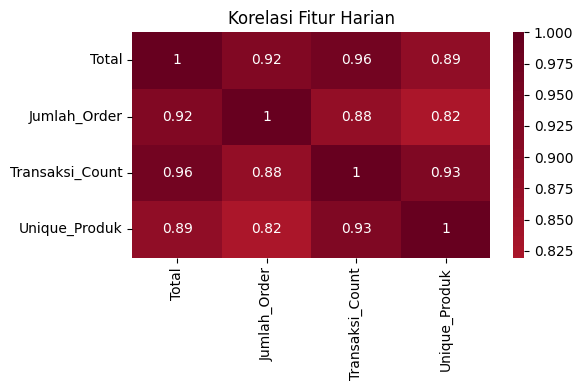

In [62]:
# Cek hubungan antar fitur harian (sekadar indikasi)
corr = daily_full[["Total", "Jumlah_Order", "Transaksi_Count", "Unique_Produk"]].corr()
display(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Korelasi Fitur Harian")
plt.tight_layout()
plt.show()


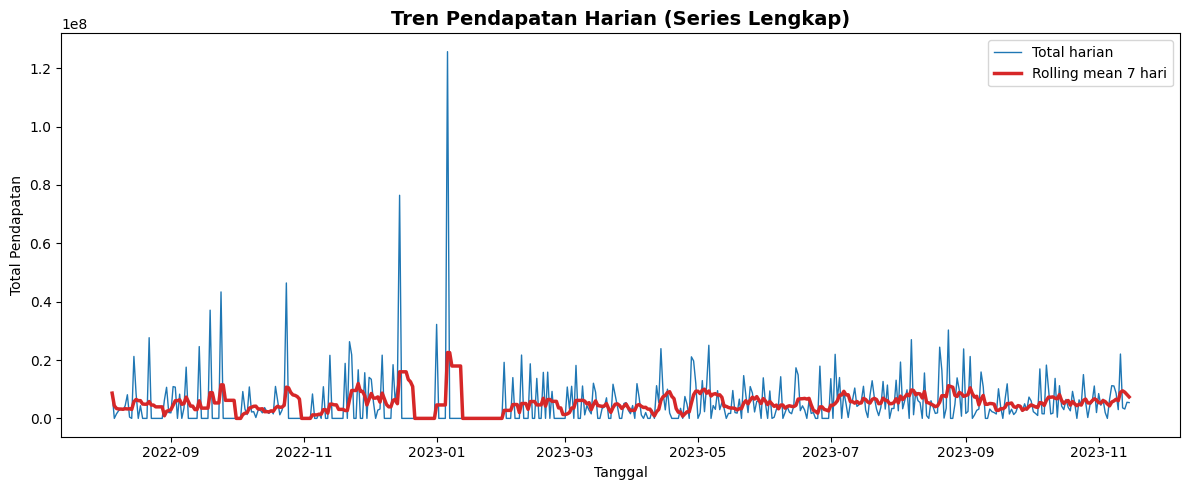

In [63]:
tmp = daily_full.copy()
tmp["Rolling7"] = tmp["Total"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=tmp, x="Tanggal", y="Total", linewidth=1.0, color="#1f77b4", label="Total harian")
sns.lineplot(data=tmp, x="Tanggal", y="Rolling7", linewidth=2.5, color="#d62728", label="Rolling mean 7 hari")
plt.title("Tren Pendapatan Harian (Series Lengkap)", fontsize=14, fontweight="bold")
plt.xlabel("Tanggal")
plt.ylabel("Total Pendapatan")
plt.legend()
plt.tight_layout()
plt.show()


Rentang data **2022-08-05 → 2023-11-15**. Dari **468 hari**, ada **184 hari** tanpa transaksi. Di sini aku isi 0 biar series-nya rapi (kalau tim menganggap itu “data hilang”, bagian ini perlu diubah).


### Pola Weekday (Deskriptif)


Menilai pola rata-rata revenue per weekday sebagai insight operasional (tanpa uji hipotesis).


,Hari,mean_total,median_total,sum_total,days,nonzero_days
1,Monday,6.658769e+06,2800000.0,446137500.0,67,43
5,Tuesday,3.644642e+06,1700000.0,244191000.0,67,42
6,Wednesday,5.355933e+06,2900000.0,358847500.0,67,44
4,Thursday,6.685947e+06,3100000.0,441272500.0,66,44
0,Friday,5.489941e+06,1500000.0,367826050.0,67,38
2,Saturday,4.790597e+06,2200000.0,320970000.0,67,41
3,Sunday,4.157767e+06,0.0,278570376.0,67,32


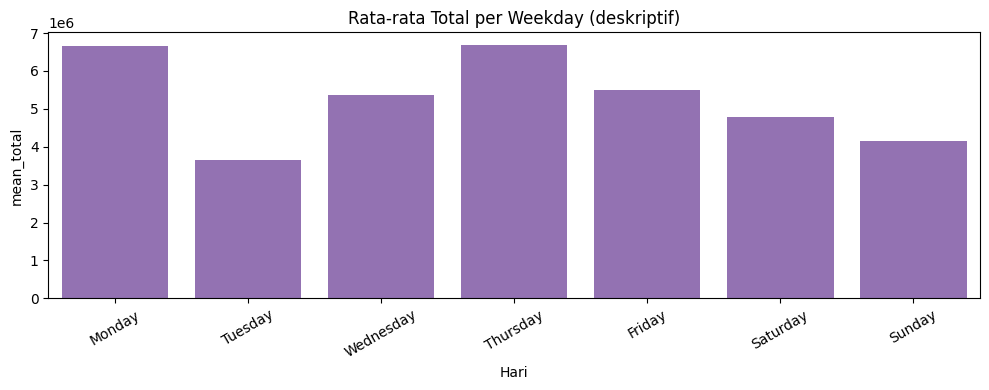

In [64]:
weekday_stats = (
    daily_full.groupby("Hari", as_index=False)
      .agg(mean_total=("Total", "mean"),
           median_total=("Total", "median"),
           sum_total=("Total", "sum"),
           days=("Total", "size"),
           nonzero_days=("Total", lambda s: int((s > 0).sum())))
)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_stats["Hari"] = pd.Categorical(weekday_stats["Hari"], categories=order, ordered=True)
weekday_stats = weekday_stats.sort_values("Hari")

display(weekday_stats)

plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_stats, x="Hari", y="mean_total", color="#9467bd")
plt.title("Rata-rata Total per Weekday (deskriptif)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


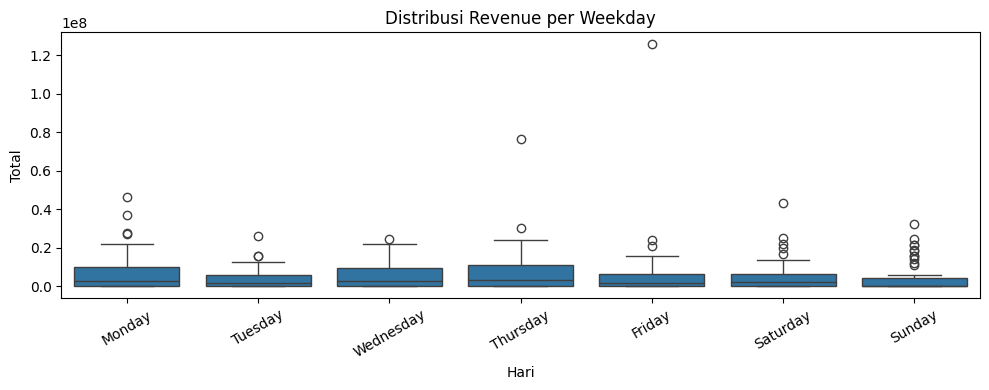

In [65]:
# Mean bisa ketarik spike, jadi cek juga distribusinya per weekday
plt.figure(figsize=(10, 4))
sns.boxplot(data=daily_full, x="Hari", y="Total", order=order)
plt.title("Distribusi Revenue per Weekday")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


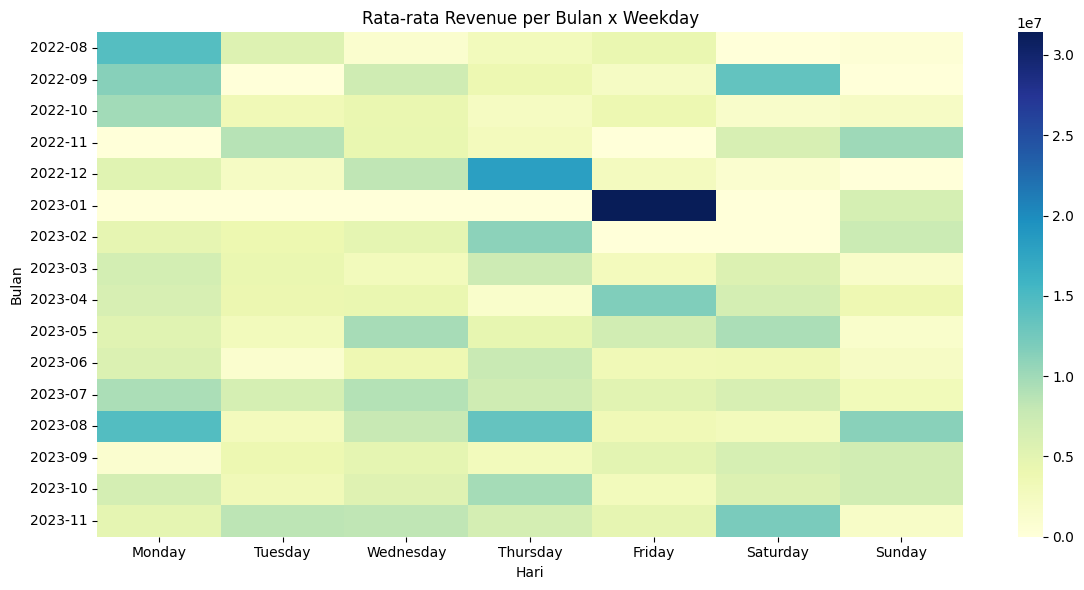

In [66]:
# Visual pola bulan x weekday (rata-rata)
heat = daily_full.copy()
heat["Bulan"] = heat["Tanggal"].dt.to_period("M").astype(str)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = heat.pivot_table(values="Total", index="Bulan", columns="Hari", aggfunc="mean").reindex(columns=order)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Rata-rata Revenue per Bulan x Weekday")
plt.tight_layout()
plt.show()


Dari heatmap ini, pola weekday belum benar-benar konsisten untuk semua bulan. Ada bulan-bulan tertentu yang terlihat lebih tinggi di hari tertentu, tapi pola itu bisa bergeser (kemungkinan karena efek order besar).


## Deteksi Perubahan Signifikan / Anomali (indikatif)


Menggunakan z-score pada total harian untuk mencari hari dengan lonjakan revenue paling tinggi.


In [67]:
series = daily_full[["Tanggal", "Total"]].copy()
mu = series["Total"].mean()
sigma = series["Total"].std(ddof=0) if series["Total"].std(ddof=0) != 0 else 1
series["z"] = (series["Total"] - mu) / sigma

top_anom = series.sort_values("z", ascending=False).head(10)
display(top_anom)


,Tanggal,Total,z
154,2023-01-06,125637500.0,12.653848
132,2022-12-15,76437500.0,7.482395
80,2022-10-24,46395000.0,4.324602
50,2022-09-24,43325000.0,4.001912
45,2022-09-19,37075000.0,3.344969
149,2023-01-01,32200000.0,2.832554
384,2023-08-24,30275000.0,2.630216
17,2022-08-22,27645000.0,2.353774
367,2023-08-07,26975000.0,2.283350
109,2022-11-22,26275000.0,2.209772


In [68]:
# Drill-down produk dominan pada hari puncak
peak_days = top_anom["Tanggal"].head(5).tolist()
peak_detail = (
    df[df["Tanggal"].isin(peak_days)]
      .groupby(["Tanggal", "Jenis Produk"], as_index=False)["Total"]
      .sum()
      .sort_values(["Tanggal", "Total"], ascending=[True, False])
)

print("Peak days:", [d.date() for d in peak_days])
peak_detail.head(40)


Peak days: [datetime.date(2023, 1, 6), datetime.date(2022, 12, 15), datetime.date(2022, 10, 24), datetime.date(2022, 9, 24), datetime.date(2022, 9, 19)]


,Tanggal,Jenis Produk,Total
0,2022-09-19,CraftLaminasi290,19100000
3,2022-09-19,Foodpak260Glossy,6250000
2,2022-09-19,Dupleks350,6200000
1,2022-09-19,Dupleks310,2125000
4,2022-09-19,FoodpakMatte245,1750000
5,2022-09-19,Ivory250,1650000
9,2022-09-24,Dupleks310,10750000
8,2022-09-24,CraftLaminasi290,9350000
11,2022-09-24,Foodpak260Glossy,7250000
14,2022-09-24,Ivory230,4450000


Ada beberapa hari spike besar (contoh Top 3: 2023-01-06 Rp125.637.500; 2022-12-15 Rp76.437.500; 2022-10-24 Rp46.395.000). Drill-down dipakai buat ngecek “produk apa yang bikin lonjakan”.


## Forecasting Prep (untuk AI Engineer)


Menyiapkan fitur (lag/rolling) dan time-based split sebagai baseline sebelum CNN-LSTM.


In [69]:
feat = daily_full.sort_values("Tanggal").reset_index(drop=True).copy()
feat["y"] = feat["Total"]  # target default: revenue

feat["lag_1"] = feat["y"].shift(1)
feat["lag_7"] = feat["y"].shift(7)
feat["roll7_mean"] = feat["y"].shift(1).rolling(7, min_periods=1).mean()
feat["roll7_std"] = feat["y"].shift(1).rolling(7, min_periods=1).std().fillna(0)
feat["roll14_mean"] = feat["y"].shift(1).rolling(14, min_periods=1).mean()

feat2 = feat.dropna(subset=["lag_7"]).copy()
print("Rows feature-ready:", len(feat2))
feat2.head(10)


Rows feature-ready: 461


,Tanggal,Total,Jumlah_Order,Transaksi_Count,Unique_Produk,Hari,Hari_Ke,y,lag_1,lag_7,roll7_mean,roll7_std,roll14_mean
7,2022-08-12,8100000.0,6500.0,5.0,4.0,Friday,4,8100000.0,4350000.0,8650000.0,3.310714e+06,2.719216e+06,3.310714e+06
8,2022-08-13,450000.0,1500.0,1.0,1.0,Saturday,5,450000.0,8100000.0,0.0,3.232143e+06,2.541354e+06,3.909375e+06
9,2022-08-14,0.0,0.0,0.0,0.0,Sunday,6,0.0,450000.0,1550000.0,3.296429e+06,2.450018e+06,3.525000e+06
10,2022-08-15,21225000.0,14500.0,8.0,7.0,Monday,0,21225000.0,0.0,2650000.0,3.075000e+06,2.692234e+06,3.172500e+06
11,2022-08-16,8450000.0,6000.0,3.0,3.0,Tuesday,1,8450000.0,21225000.0,3175000.0,5.728571e+06,7.342122e+06,4.813636e+06
12,2022-08-17,0.0,0.0,0.0,0.0,Wednesday,2,0.0,8450000.0,2800000.0,6.482143e+06,7.306970e+06,5.116667e+06
13,2022-08-18,4325000.0,3000.0,4.0,4.0,Thursday,3,4325000.0,0.0,4350000.0,6.082143e+06,7.612390e+06,4.723077e+06
14,2022-08-19,0.0,0.0,0.0,0.0,Friday,4,0.0,4325000.0,8100000.0,6.078571e+06,7.613344e+06,4.694643e+06
15,2022-08-20,0.0,0.0,0.0,0.0,Saturday,5,0.0,0.0,450000.0,4.921429e+06,7.866257e+06,4.076786e+06
16,2022-08-21,0.0,0.0,0.0,0.0,Sunday,6,0.0,0.0,0.0,4.857143e+06,7.910604e+06,4.076786e+06


In [70]:
# Time-based split (tanpa shuffle)
n = len(feat2)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = feat2.iloc[:train_end]
val = feat2.iloc[train_end:val_end]
test = feat2.iloc[val_end:]

print("Train/Val/Test:", train.shape, val.shape, test.shape)
print("Train range:", train["Tanggal"].min().date(), "->", train["Tanggal"].max().date())
print("Val range  :", val["Tanggal"].min().date(), "->", val["Tanggal"].max().date())
print("Test range :", test["Tanggal"].min().date(), "->", test["Tanggal"].max().date())


Train/Val/Test: (322, 13) (69, 13) (70, 13)
Train range: 2022-08-12 -> 2023-06-29
Val range  : 2023-06-30 -> 2023-09-06
Test range : 2023-09-07 -> 2023-11-15


lag/rolling ini aku taruh buat cek cepat apakah pola mingguan/tren lokal kebaca. Split tetap berbasis waktu (tanpa shuffle) biar tidak bocor.

**Keterbatasan data:** data hanya **468 hari** dan banyak hari 0 transaksi, jadi forecasting nanti kemungkinan sensitif terhadap spike order besar.

### Export Dataset (handoff AI Engineer & Streamlit)


Menyimpan dataset bersih dan dataset harian agar bisa dipakai langsung.


In [71]:
OUT_TRANS = Path("transaksi_clean.csv")
OUT_DAILY = Path("sales_daily.csv")
OUT_DAILY_PROD = Path("sales_daily_by_product.csv")
OUT_DAILY_FEAT = Path("sales_daily_features.csv")

# transaksi-level bersih
df.to_csv(OUT_TRANS, index=False)

# series harian lengkap
daily_full.to_csv(OUT_DAILY, index=False)

# harian per produk (opsional untuk filter dashboard)
daily_by_product = (
    df.groupby(["Tanggal", "Jenis Produk"], as_index=False)["Total"]
      .sum()
      .sort_values(["Tanggal", "Total"], ascending=[True, False])
)
daily_by_product.to_csv(OUT_DAILY_PROD, index=False)

# fitur kandidat (opsional)
feat2.to_csv(OUT_DAILY_FEAT, index=False)

print("Saved:", OUT_TRANS.resolve())
print("Saved:", OUT_DAILY.resolve())
print("Saved:", OUT_DAILY_PROD.resolve())
print("Saved:", OUT_DAILY_FEAT.resolve())


Saved: /content/transaksi_clean.csv
Saved: /content/sales_daily.csv
Saved: /content/sales_daily_by_product.csv
Saved: /content/sales_daily_features.csv


## Data Dictionary

- Tanggal: Tanggal transaksi (datetime)
- Jenis Produk: Nama produk/material
- Jumlah Order: Jumlah/volume order
- Harga: Harga satuan
- Total: Total revenue transaksi (Jumlah Order * Harga)
- Tahun: Tahun dari Tanggal
- Bulan: Bulan dari Tanggal (YYYY-MM)
- Hari: Nama hari (Monday..Sunday)
- Hari_Ke: Index hari (0=Monday ... 6=Sunday)

## Ringkasan Reasoning Bisnis

- Revenue terlihat **cukup terkonsentrasi**: sekitar **14 produk** sudah menutup ~80% total revenue. Artinya perubahan revenue besar kemungkinan banyak dipengaruhi performa produk inti.
- Tren harian cenderung **spiky** (ada beberapa hari lonjakan besar). Ditambah hasil drill-down di hari puncak, ini lebih mengarah ke **order besar di hari tertentu** daripada kenaikan yang stabil dari hari ke hari.
- Dari analisis weekday + heatmap bulan×weekday, pola weekday **tidak selalu konsisten** antar bulan. Jadi faktor operasional/event (order besar, kebutuhan stok mendadak, dll) tampak lebih dominan dibanding pola musiman sederhana.
- Data harian total **468 hari** dengan **184 hari tanpa transaksi**. Kondisi ini bikin forecasting berpotensi sensitif terhadap outlier/spike, sehingga perlu hati-hati di preprocessing (mis. scaling, dan strategi handling spike saat modeling).


## Conclusion


**Conclusion – Jawaban pertanyaan bisnis:**

1) **Tren & perubahan signifikan:** bulan puncak terjadi di **2023-08** (≈ **Rp247.747.500**) dan ada beberapa hari spike besar. Kemungkinan besar spike ini muncul karena order besar pada hari tertentu, bukan karena kenaikan stabil setiap hari.

2) **Produk kontributor terbesar:** revenue cukup terpusat; sekitar **14 produk** sudah menutup ~80% revenue. Jadi lebih masuk akal mulai dari produk inti dulu untuk perencanaan stok/bahan.

3) **Rekomendasi tindakan:** jaga stok/bahan untuk produk inti, dan siapkan SOP singkat untuk hari order besar (mis. cek stok, kapasitas produksi, dan lead time supplier).

4) **Kesiapan forecasting 7 hari:** `sales_daily.csv` sudah jadi series harian kontinu (gap diisi 0) untuk training forecasting. Fitur kandidat opsional tersedia di `sales_daily_features.csv`.

5) **Limitasi:** data hanya **468 hari** dan ada **184 hari** tanpa transaksi, jadi model forecasting kemungkinan sensitif terhadap spike order besar.
